# <a id='toc1_'></a>[Предсказание стоимости дома](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Предсказание стоимости дома](#toc1_)    
  - [Описание проекта](#toc1_1_)    
  - [Начало работы](#toc1_2_)    
  - [Активация Spark сессии](#toc1_3_)    
  - [Загрузка данных](#toc1_4_)    
  - [Проверка предобработки](#toc1_5_)    
  - [Исследовательский анализ данных](#toc1_6_)    
    - [Медианный возраст жителей](#toc1_6_1_)    
    - [Общее число комнат](#toc1_6_2_)    
    - [Общее число спален](#toc1_6_3_)    
    - [Количество домовладений](#toc1_6_4_)    
    - [Количество жителей](#toc1_6_5_)    
    - [Медианный доход жителей](#toc1_6_6_)    
    - [Медианная стоимость дома](#toc1_6_7_)    
    - [Отношение количества комнат к количеству домовладений](#toc1_6_8_)    
    - [Отношение количества жителей к количеству домовладений](#toc1_6_9_)    
    - [Отношение количества спален к общему количеству комнат](#toc1_6_10_)    
    - [Близость к океану](#toc1_6_11_)    
    - [Фильтрация датасета](#toc1_6_12_)    
  - [Корреляционный анализ](#toc1_7_)    
  - [Подготовка пайплайна](#toc1_8_)    
  - [Оценка качества моделей](#toc1_9_)    
  - [Остановка Spark сессии](#toc1_10_)    
  - [Вывод](#toc1_11_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## <a id='toc1_1_'></a>[Описание проекта](#toc0_)

**Цель:** На основе данных нужно предсказать медианную стоимость дома в жилом массиве в Калифорнии.

**Задачи:** 
1. Обучить модель линейной регрессии, используя и количественные, и категориальные признаки
2. Обучить модель линейной регрессии, используя только количественные признаки
3. Сравнить обе модели метриками RMSE, MAE и R2

**Данные:** данные были собраны в рамках переписи населения в США. Каждая строка содержит агрегированную статистику о жилом массиве в Калифорнии за 1990 год. Жилой массив — минимальная географическая единица с населением от 600 до 3000 человек в зависимости от штата. Одна строка в данных содержит статистику в среднем о 1425.5 обитателях жилого массива.

- `housing_median_age` — медианный возраст жителей жилого массива;
- `total_rooms` — общее количество комнат в домах жилого массива;
- `total_bedrooms` — общее количество спален в домах жилого массива;
- `population` — количество человек, которые проживают в жилом массиве;
- `households` — количество домовладений в жилом массиве;
- `median_income` — медианный доход жителей жилого массива;
- `median_house_value` — медианная стоимость дома в жилом массиве;
- `ocean_proximity` — близость к океану;
- `rooms_per_household` - отношение количества комнат к количеству домовладений;
- `population_in_household` - отношение количества жителей к количеству домовладений;
- `bedroom_index` - отношение количества спален к общему количеству комнат.

## <a id='toc1_2_'></a>[Начало работы](#toc0_)

In [1]:
!pip install --upgrade matplotlib==3.9.0 seaborn==0.13.2 -q

In [2]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.functions import log1p
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.stat import Correlation

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

RANDOM_SEED=42

%matplotlib inline
plt.rcParams['figure.dpi'] = 120


## <a id='toc1_3_'></a>[Активация Spark сессии](#toc0_)

In [3]:
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"

spark = SparkSession.builder.master("local[*]").appName("California Housing Project").getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/06/20 14:36:47 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## <a id='toc1_4_'></a>[Загрузка данных](#toc0_)

В процессе выполнения промежуточного практического задания на портале, данные были предобработаны, проведен EDA.

In [4]:
# Вариант для локальной загрузки данных
try:
    df = spark.read.load('data_primary.csv', format='csv', sep=',', inferSchema=True, header='true')

# Вариант для запуска с сервера яндекс практикума
except:
    df = spark.read.load('/datasets/housing.csv', format='csv', sep=',', inferSchema=True, header='true')
    
df.printSchema()
df.show(10)

root
 |-- longitude: double (nullable = true)
 |-- latitude: double (nullable = true)
 |-- housing_median_age: double (nullable = true)
 |-- total_rooms: double (nullable = true)
 |-- total_bedrooms: double (nullable = true)
 |-- population: double (nullable = true)
 |-- households: double (nullable = true)
 |-- median_income: double (nullable = true)
 |-- median_house_value: double (nullable = true)
 |-- ocean_proximity: string (nullable = true)

+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+
|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|ocean_proximity|
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+
|  -122.23|   37.88|              41.0|      880.0|         129.0|     322.0|     126.0|       8.3252|          452600.0|       NEAR B

## <a id='toc1_5_'></a>[Проверка предобработки](#toc0_)

Изучим пропуски и нулевые значения:

In [5]:
for column in df.columns:
    check_col = F.isnan(F.col(column)) | F.isnull(F.col(column))
    print(column, df.filter(check_col).count())

longitude 0
latitude 0
housing_median_age 0
total_rooms 0
total_bedrooms 207
population 0
households 0
median_income 0
median_house_value 0
ocean_proximity 0


In [6]:
# Вычисляем медиану
median = df.approxQuantile("total_bedrooms", [0.5], 0.0)[0]
print(median)

# Заполняем null медианой
df = df.fillna({"total_bedrooms": median})

435.0


In [7]:
def spark_df_info(df, value_limit=20):
    total_rows = df.count()
    duplicate_count = total_rows - df.dropDuplicates().count()

    print(f"Размер датафрейма: ({total_rows}, {len(df.columns)})")
    print(f"Кол-во строк-дубликатов: {duplicate_count}")

    summary = []
    col_dtype = dict(df.dtypes)

    for col in df.columns:
        # Агрегация not_na, null, unique_count
        agg = df.select(
            F.count(col).alias("not_na"),
            F.sum(F.when(F.col(col).isNull(), 1).otherwise(0)).alias("null"),
            F.countDistinct(col).alias("unique_count")
        ).first()

        # Уникальные значения
        unique = df.select(col).distinct().limit(value_limit).agg(
                F.collect_list(col).alias("unique_values")
            ).first()["unique_values"]
        
        summary.append({
            "column": col,
            "dtype": col_dtype[col],
            "not_na": agg["not_na"],
            "null": agg["null"],
            "unique_count": agg["unique_count"],
            "unique_values": unique
        })

    # Переводим в pandas DataFrame
    summary_df = pd.DataFrame(summary).set_index("column")
    return summary_df

In [8]:
spark_df_info(df)

Размер датафрейма: (20640, 10)
Кол-во строк-дубликатов: 0


,dtype,not_na,null,unique_count,unique_values
column,,,,,
longitude,double,20640,0,844,"[-119.04, -122.61, -121.27, -122.02, -120.88, ..."
latitude,double,20640,0,862,"[37.81, 38.61, 40.11, 35.17, 40.53, 39.42, 40...."
housing_median_age,double,20640,0,52,"[8.0, 7.0, 49.0, 29.0, 47.0, 42.0, 44.0, 35.0,..."
total_rooms,double,20640,0,5926,"[769.0, 2862.0, 3980.0, 1761.0, 692.0, 4800.0,..."
total_bedrooms,double,20640,0,1923,"[299.0, 305.0, 769.0, 496.0, 558.0, 596.0, 934..."
population,double,20640,0,3888,"[496.0, 558.0, 299.0, 769.0, 596.0, 1761.0, 93..."
households,double,20640,0,1815,"[496.0, 769.0, 299.0, 1051.0, 305.0, 558.0, 69..."
median_income,double,20640,0,12928,"[2.9044, 5.1039, 2.3243, 1.6023, 1.9939, 2.562..."
median_house_value,double,20640,0,3842,"[270100.0, 330000.0, 179300.0, 217000.0, 30000..."


In [9]:
df.describe().toPandas()

,summary,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,count,20640,20640,20640,20640,20640,20640,20640,20640,20640,20640
1,mean,-119.56970445736148,35.6318614341087,28.639486434108527,2635.7630813953488,536.8388565891473,1425.4767441860465,499.5396802325581,3.8706710029070246,206855.81690891474,None
2,stddev,2.003531723502584,2.135952397457101,12.58555761211163,2181.6152515827944,419.39187792168866,1132.46212176534,382.3297528316098,1.899821717945263,115395.61587441359,None
3,min,-124.35,32.54,1.0,2.0,1.0,3.0,1.0,0.4999,14999.0,<1H OCEAN
4,max,-114.31,41.95,52.0,39320.0,6445.0,35682.0,6082.0,15.0001,500001.0,NEAR OCEAN


## <a id='toc1_6_'></a>[Исследовательский анализ данных](#toc0_)

In [10]:
def show_box_hist_plots (
    df,
    col,
    bins = 100,
    title = 'Распределение значений',
    xlabel = None,
    return_bounds = False,
    value_limit = 0
):
    # Загружаем данные из Spark в Pandas
    data = df.limit(value_limit).toPandas()[col]
    
    # Строим графики
    _, ax = plt.subplots(2, sharex = True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(8,6))
    sns.histplot(x = data, ax = ax[1], bins = bins, color = '#ff7f0e')
    sns.boxplot(x = data, ax = ax[0], orient = 'h', color = '#ff7f0e')
    ax[0].set(title = title)
    ax[1].set(ylabel = 'Количество значений, шт', xlabel = xlabel)
    plt.subplots_adjust(top=0.8)
    plt.show()

    # Расчёт статистик и границ выбросов
    q_1 = np.quantile(data, 0.25)
    q_3 = np.quantile(data, 0.75)
    IQR = q_3 - q_1
    lower_bound = q_1 - 3*IQR
    upper_bound = q_3 + 3*IQR

    # Печатаем основные статистики
    print(f'Среднее: {data.mean()}')
    print(f'Медиана: {data.median()}')
    print(f'Мода: {data.mode()[0]}')
    print(f'Стандартное отклонение: {data.std()}')
    print(f'Q1-3*IQR: {lower_bound}')
    print(f'Q3+3*IQR: {upper_bound}')

    # Возвращаем границы выбросов при необходимости
    if return_bounds:
        return lower_bound, upper_bound

In [11]:
def show_barplot_pie (
    df,
    col, 
    title = 'Диаграмма',
    value_limit = 0
    ):

    # Загружаем данные из Spark в Pandas
    data = df.limit(value_limit).toPandas()[col]
    
    # Создадим фигуру
    fig, ax = plt.subplots(1, 2, figsize=(12,6))
    
    # Передадим в переменную распределение значений
    value_counts_result = data.value_counts().sort_index() 
    
    # Определим цвет колонок
    colors = sns.color_palette("Paired", len(value_counts_result))
    
    # Создадим столбчатой диаграммы
    sns.barplot(
        x=value_counts_result.index,
        hue=value_counts_result.index,
        y=value_counts_result.values,
        ax = ax[0],
        palette = colors
    )

    # Зададим подпись оси Y
    ax[0].set(ylabel = 'Количество значений, шт', xlabel = None)
    
    # Отображение значений для каждого столбца
    for index, value in enumerate(value_counts_result):
        ax[0].text(index, 50, str(value), ha='center', fontsize=12, color='#000000')
        ax[0].tick_params(axis='x', rotation=90)
        
    # Создание круговой диаграммы
    ax[1].pie(
        value_counts_result,
        labels = value_counts_result.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors
    )
    # Подпись каждой диаграммы
    ax[0].set_title('Столбчатая диаграмма', fontsize=16)
    ax[1].set_title('Круговая диаграмма', fontsize=16)
    fig.suptitle(title, fontsize=20)
    plt.subplots_adjust(top=0.8)
    plt.tight_layout()
    
    # Уберем легенду, если она существует
    legend = ax[0].get_legend()
    if legend:
        legend.remove()
    
    plt.show()

### <a id='toc1_6_1_'></a>[Медианный возраст жителей](#toc0_)

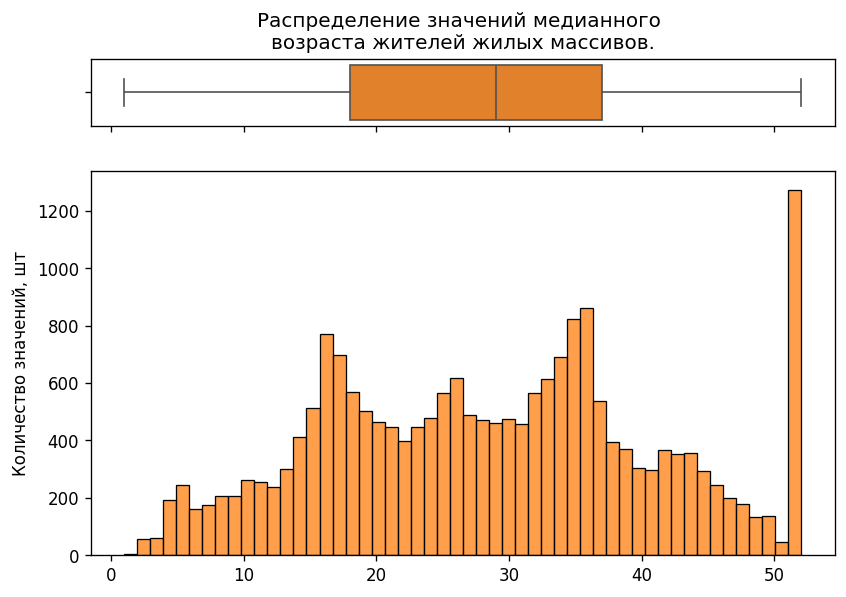

Среднее: 28.639486434108527
Медиана: 29.0
Мода: 52.0
Стандартное отклонение: 12.58555761211165
Q1-3*IQR: -39.0
Q3+3*IQR: 94.0


In [12]:
show_box_hist_plots(
    df,
    col = 'housing_median_age',
    value_limit = 20640,
    bins = 52,
    title = 'Распределение значений медианного \nвозраста жителей жилых массивов.',
    return_bounds=False)

### <a id='toc1_6_2_'></a>[Общее число комнат](#toc0_)

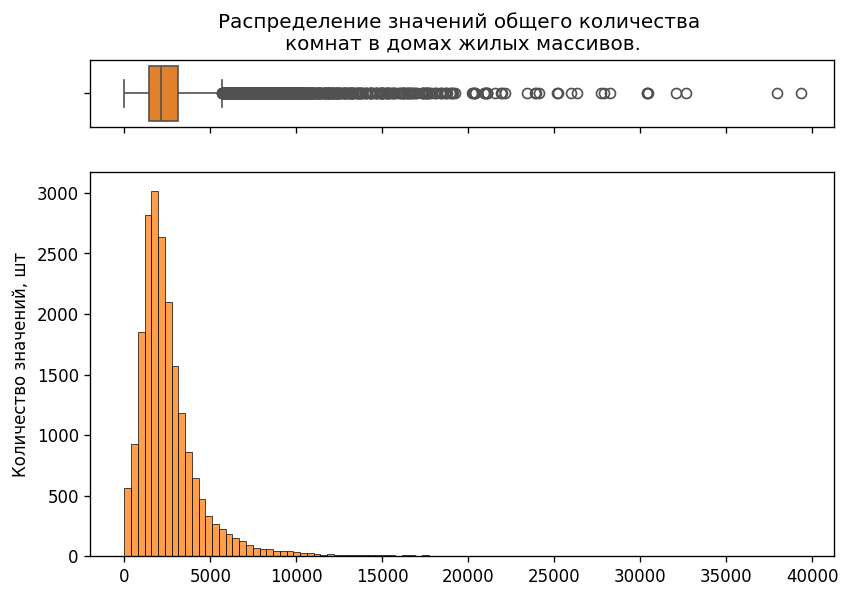

Среднее: 2635.7630813953488
Медиана: 2127.0
Мода: 1527.0
Стандартное отклонение: 2181.615251582795
Q1-3*IQR: -3653.0
Q3+3*IQR: 8248.75


In [13]:
_, total_rooms_upper = show_box_hist_plots(
    df,
    col = 'total_rooms',
    value_limit = 20640,
    bins = 100,
    title = 'Распределение значений общего количества \nкомнат в домах жилых массивов.',
    return_bounds=True)

### <a id='toc1_6_3_'></a>[Общее число спален](#toc0_)

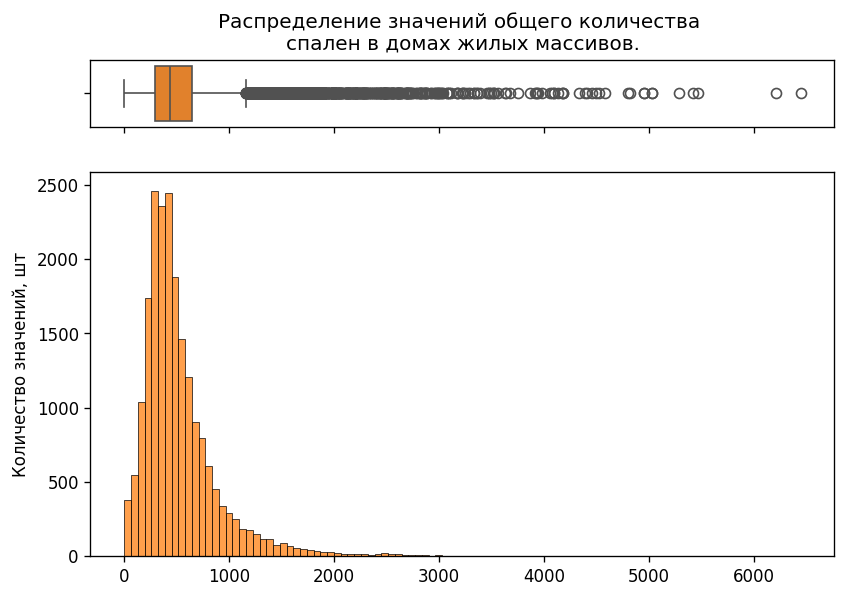

Среднее: 536.8388565891473
Медиана: 435.0
Мода: 435.0
Стандартное отклонение: 419.3918779216883
Q1-3*IQR: -741.75
Q3+3*IQR: 1682.0


In [14]:
_, total_bedrooms_upper = show_box_hist_plots(
    df,
    col = 'total_bedrooms',
    value_limit = 20640,    
    bins = 100,
    title = 'Распределение значений общего количества \nспален в домах жилых массивов.',
    return_bounds=True)

### <a id='toc1_6_4_'></a>[Количество домовладений](#toc0_)

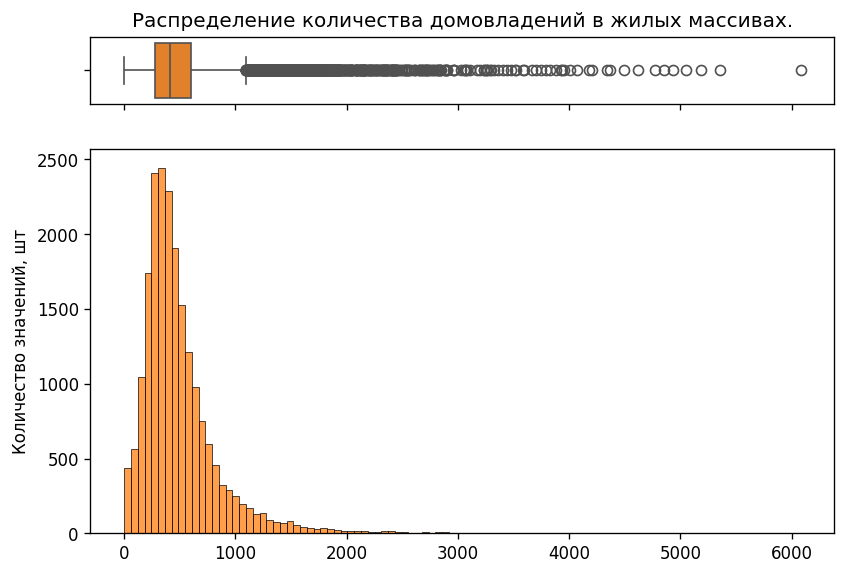

Среднее: 499.5396802325581
Медиана: 409.0
Мода: 306.0
Стандартное отклонение: 382.32975283161073
Q1-3*IQR: -695.0
Q3+3*IQR: 1580.0


In [15]:
_, households_upper = show_box_hist_plots(
    df,
    col = 'households',
    value_limit = 20640,
    bins = 100,
    title = 'Распределение количества домовладений в жилых массивах.',
    return_bounds=True)

### <a id='toc1_6_5_'></a>[Количество жителей](#toc0_)

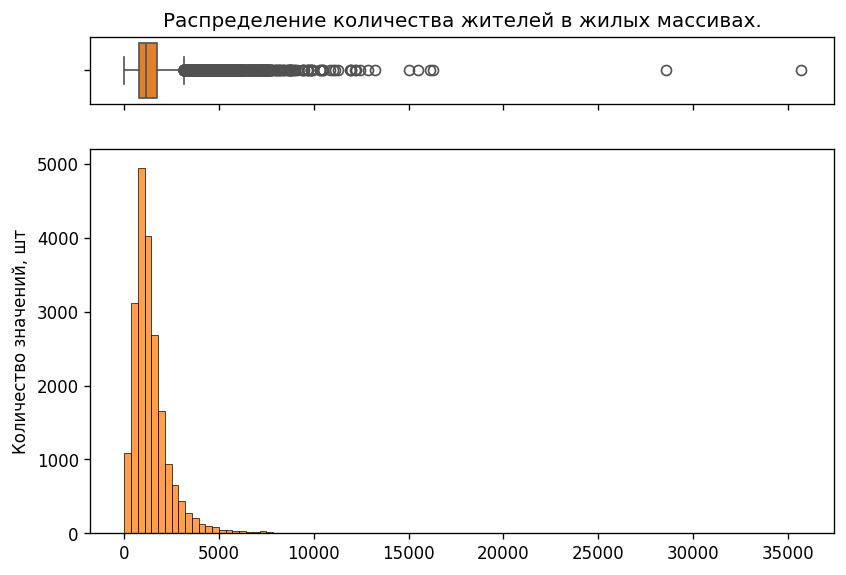

Среднее: 1425.4767441860465
Медиана: 1166.0
Мода: 891.0
Стандартное отклонение: 1132.462121765341
Q1-3*IQR: -2027.0
Q3+3*IQR: 4539.0


In [16]:
_, population_upper = show_box_hist_plots(
    df,
    col = 'population',
    value_limit = 20640,
    bins = 100,
    title = 'Распределение количества жителей в жилых массивах.',
    return_bounds=True)

### <a id='toc1_6_6_'></a>[Медианный доход жителей](#toc0_)

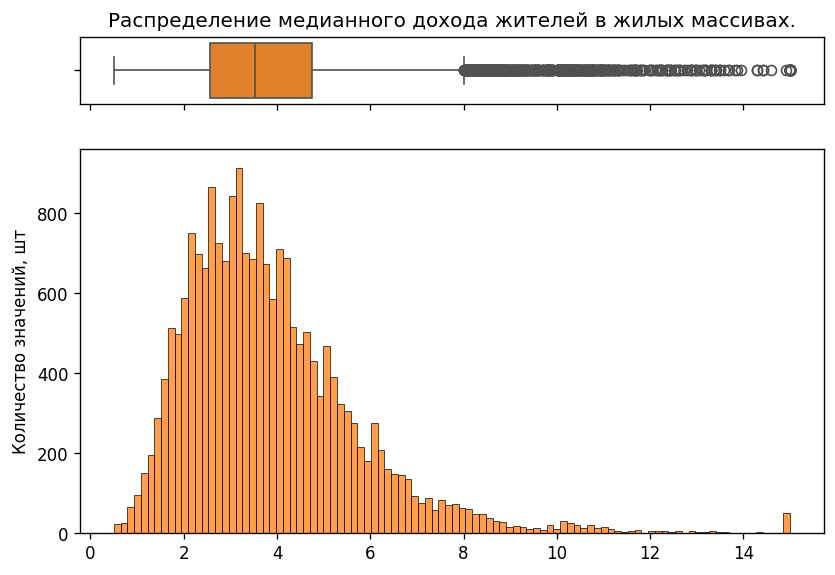

Среднее: 3.8706710029069766
Медиана: 3.5347999999999997
Мода: 3.125
Стандартное отклонение: 1.8998217179452688
Q1-3*IQR: -3.9761500000000005
Q3+3*IQR: 11.2828


In [17]:
show_box_hist_plots(
    df,
    col = 'median_income',
    value_limit = 20640,
    bins = 100,
    title = 'Распределение медианного дохода жителей в жилых массивах.',
    return_bounds=False)

Логирифмируем признак, чтобы распределение было ближе к нормальному.

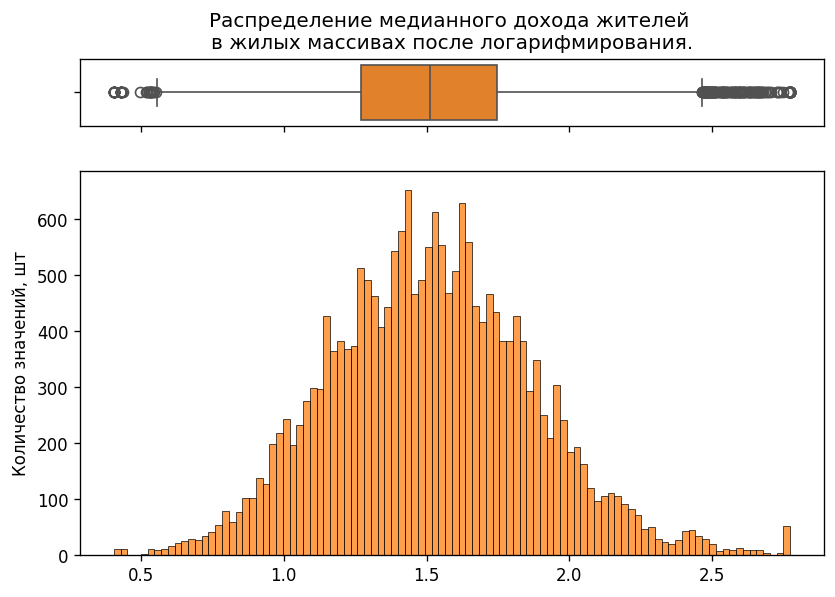

Среднее: 1.5169950433863728
Медиана: 1.511780980918168
Мода: 1.4170660197866443
Стандартное отклонение: 0.3586774123577948
Q1-3*IQR: -0.16121521496178404
Q3+3*IQR: 3.1799556007635603


In [18]:
df = df.withColumn('log_median_income', log1p('median_income'))

show_box_hist_plots(
    df,
    col = 'log_median_income',
    value_limit = 20640,
    bins = 100,
    title = 'Распределение медианного дохода жителей \nв жилых массивах после логарифмирования.',
    return_bounds=False)

### <a id='toc1_6_7_'></a>[Медианная стоимость дома](#toc0_)

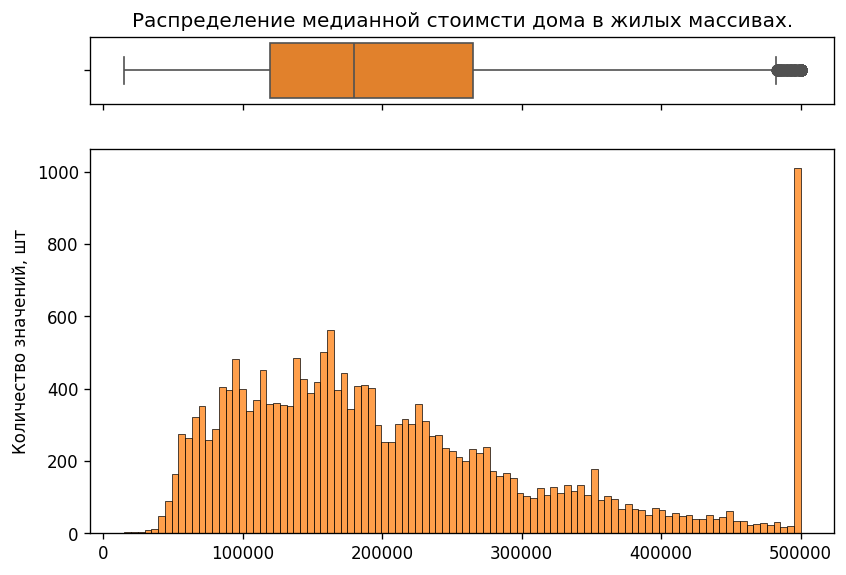

Среднее: 206855.81690891474
Медиана: 179700.0
Мода: 500001.0
Стандартное отклонение: 115395.61587441387
Q1-3*IQR: -315775.0
Q3+3*IQR: 700100.0


In [19]:
show_box_hist_plots(
    df,
    col = 'median_house_value',
    value_limit = 20640,
    bins = 100,
    title = 'Распределение медианной стоимсти дома в жилых массивах.',
    return_bounds=False)

### <a id='toc1_6_8_'></a>[Отношение количества комнат к количеству домовладений](#toc0_)

In [20]:
df = df.withColumn('rooms_per_household', F.col('total_rooms') / F.col('households'))

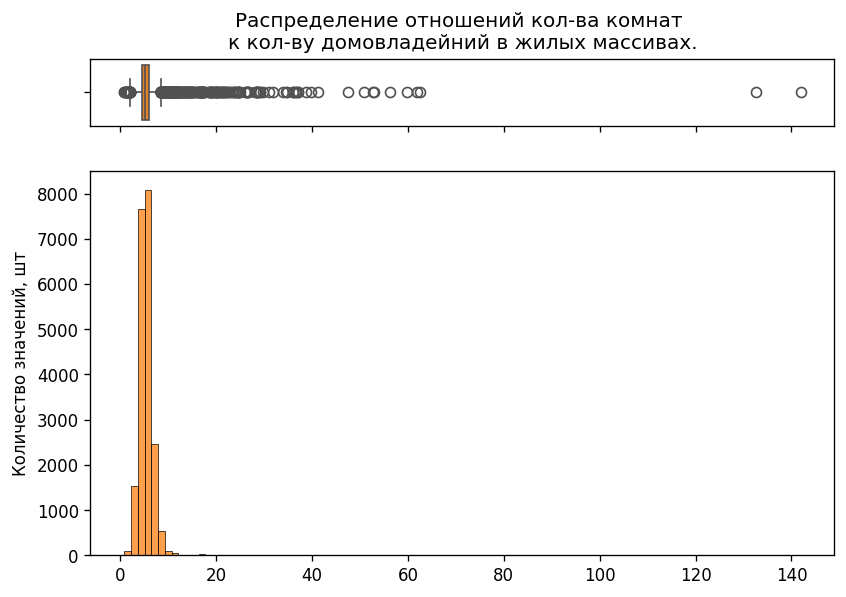

Среднее: 5.428999742190376
Медиана: 5.229128787878788
Мода: 5.0
Стандартное отклонение: 2.4741731394243187
Q1-3*IQR: -0.39427791355502073
Q3+3*IQR: 10.887375101832932


In [21]:
_, rooms_per_household_upper = show_box_hist_plots(
    df,
    col = 'rooms_per_household',
    value_limit = 20640,
    bins = 100,
    title = 'Распределение отношений кол-ва комнат \nк кол-ву домовладейний в жилых массивах.',
    return_bounds=True)

### <a id='toc1_6_9_'></a>[Отношение количества жителей к количеству домовладений](#toc0_)

In [22]:
df = df.withColumn('population_in_household', F.col('population') / F.col('households'))

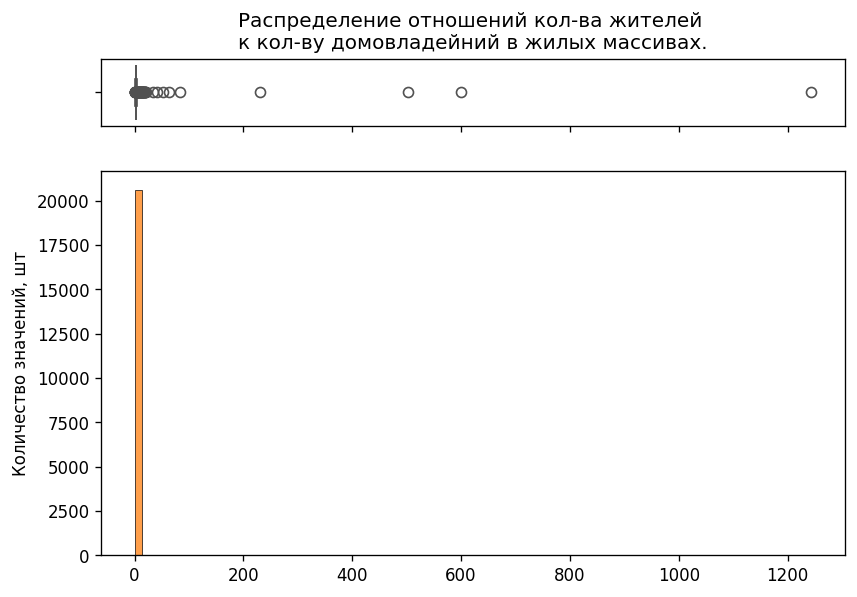

Среднее: 3.0706551594363742
Медиана: 2.818115654360196
Мода: 3.0
Стандартное отклонение: 10.386049562213618
Q1-3*IQR: -0.12781818260656275
Q3+3*IQR: 5.83982025443376


In [23]:
_, population_in_household_upper = show_box_hist_plots(
    df,
    col = 'population_in_household',
    value_limit = 20640,
    bins = 100,
    title = 'Распределение отношений кол-ва жителей \nк кол-ву домовладейний в жилых массивах.',
    return_bounds=True)

### <a id='toc1_6_10_'></a>[Отношение количества спален к общему количеству комнат](#toc0_)

In [24]:
df = df.withColumn('bedroom_index', F.col('total_bedrooms') / F.col('total_rooms'))

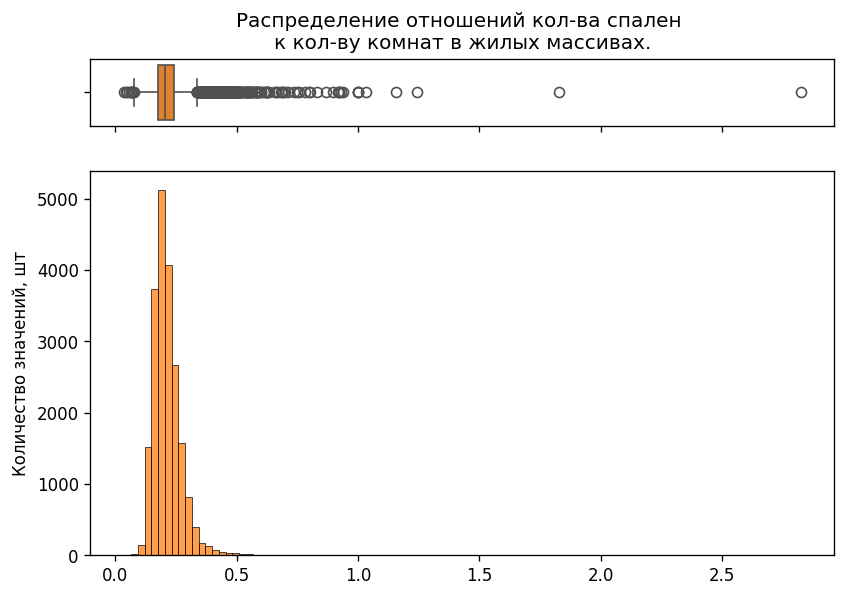

Среднее: 0.21379409952597075
Медиана: 0.20315912632819494
Мода: 0.25
Стандартное отклонение: 0.06524816735448492
Q1-3*IQR: -0.01948004578629184
Q3+3*IQR: 0.4348310172663202


In [25]:
_, bedroom_index_upper = show_box_hist_plots(
    df,
    col = 'bedroom_index',
    value_limit = 20640,
    bins = 100,
    title = 'Распределение отношений кол-ва спален \nк кол-ву комнат в жилых массивах.',
    return_bounds=True)

### <a id='toc1_6_11_'></a>[Близость к океану](#toc0_)

Только один признак относится к категориальным - `ocean_proximity`. 

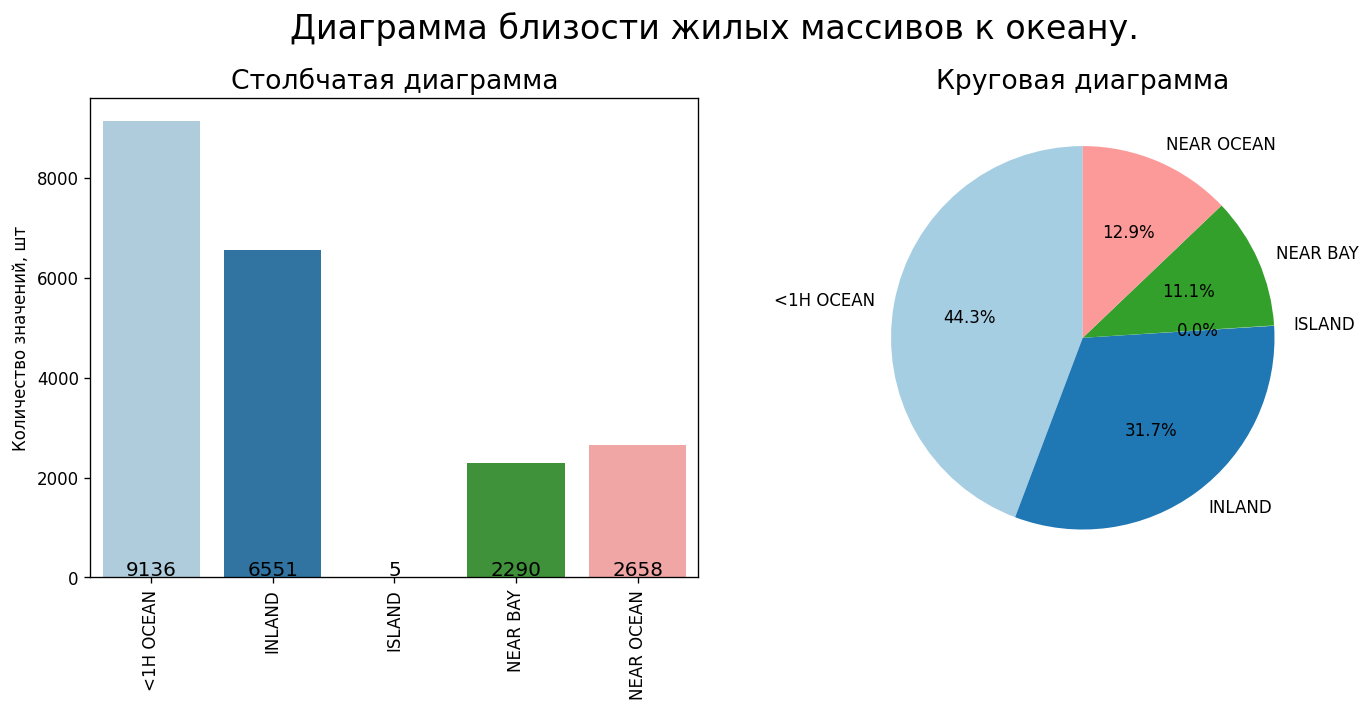

In [26]:
show_barplot_pie(
    df,
    col = 'ocean_proximity',
    value_limit = 20640,
    title = 'Диаграмма близости жилых массивов к океану.'
    )

### <a id='toc1_6_12_'></a>[Фильтрация датасета](#toc0_)

Для признаков с сильными выбросами ограничим диапазон значений в пределах 3 IQR. Создадим новый датасет с отфильтрованными данными.

In [27]:
df_filtered = df.filter(
    (df['total_rooms'] <= total_rooms_upper) &
    (df['total_bedrooms'] <= total_bedrooms_upper) &
    (df['population'] <= population_upper) &
    (df['households'] <= households_upper) &
    (df['rooms_per_household'] <= rooms_per_household_upper) &
    (df['population_in_household'] <= population_in_household_upper) &
    (df['bedroom_index'] <= bedroom_index_upper)
).select(
    'housing_median_age',
    'total_rooms',
    'total_bedrooms',
    'population',
    'households',
    'log_median_income',
    'median_house_value',
    'rooms_per_household',
    'population_in_household',
    'bedroom_index',
    'ocean_proximity'
    )
print('Кол-во строк до фильтрации:', df.count())
print('Кол-во строк после фильтрации:', df_filtered.count())
df_filtered.show(10)

Кол-во строк до фильтрации: 20640
Кол-во строк после фильтрации: 19506
+------------------+-----------+--------------+----------+----------+------------------+------------------+-------------------+-----------------------+-------------------+---------------+
|housing_median_age|total_rooms|total_bedrooms|population|households| log_median_income|median_house_value|rooms_per_household|population_in_household|      bedroom_index|ocean_proximity|
+------------------+-----------+--------------+----------+----------+------------------+------------------+-------------------+-----------------------+-------------------+---------------+
|              41.0|      880.0|         129.0|     322.0|     126.0|2.2327204130210596|          452600.0|  6.984126984126984|     2.5555555555555554|0.14659090909090908|       NEAR BAY|
|              21.0|     7099.0|        1106.0|    2401.0|    1138.0|2.2301649264639662|          358500.0|  6.238137082601054|      2.109841827768014|0.15579659106916466|      

## <a id='toc1_7_'></a>[Корреляционный анализ](#toc0_)

In [28]:
num_cols = [
    'housing_median_age',
    'total_rooms', 
    'total_bedrooms', 
    'population',
    'households', 
    #'median_income', 
    'log_median_income',
    'rooms_per_household', 
    'population_in_household', 
    'bedroom_index'
    ]


ohe_cols = ['ocean_proximity']
target = 'median_house_value'

In [29]:
def plot_spark_corr_matrix(df, input, method):
    # Собираем вектор признаков
    assembler = VectorAssembler(inputCols=input, outputCol="__corr_vector__")
    vector = assembler.transform(df).select("__corr_vector__")

    # Считаем корреляционную матрицу
    correlation_matrix = Correlation.corr(vector, "__corr_vector__", method=method).head()[0]
    corr_array = correlation_matrix.toArray()

    # Визуализируем
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_array, xticklabels=input, yticklabels=input, annot=True, cmap='coolwarm')
    plt.title("Корреляционная матрица")
    plt.show()

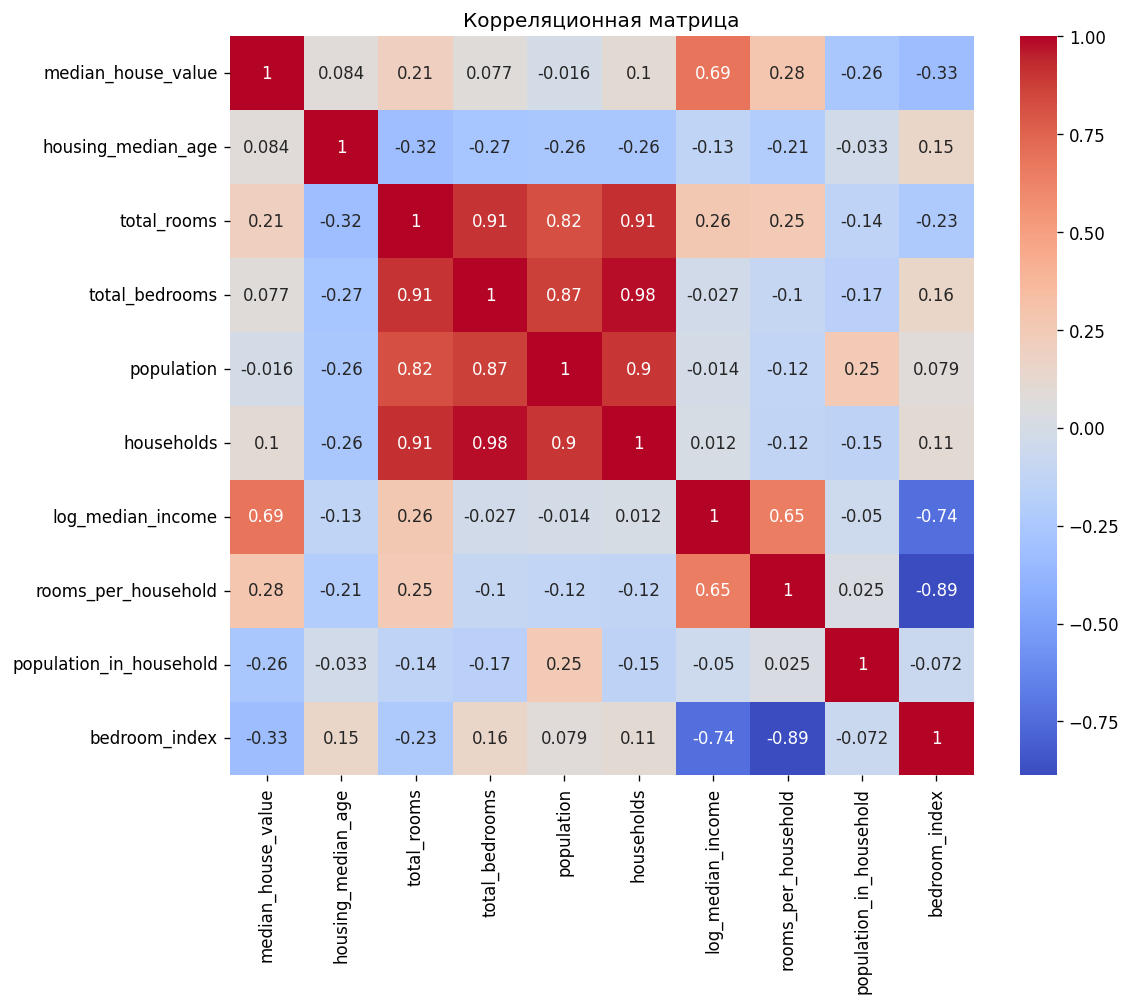

In [30]:
plot_spark_corr_matrix(df=df_filtered, input=([target]+num_cols), method='spearman')

Присутствует мультиколлинеарность, удалим некоторые признаки и проверим качество модели. Эмпирическим путем подберем лучшую комбинацию признаков.

In [31]:
to_drop = [
    'total_bedrooms',
    'households',
    'rooms_per_household', 
    #'population_in_household',
    #'population'
]

num_cols_filtered = [col for col in num_cols if col not in to_drop]

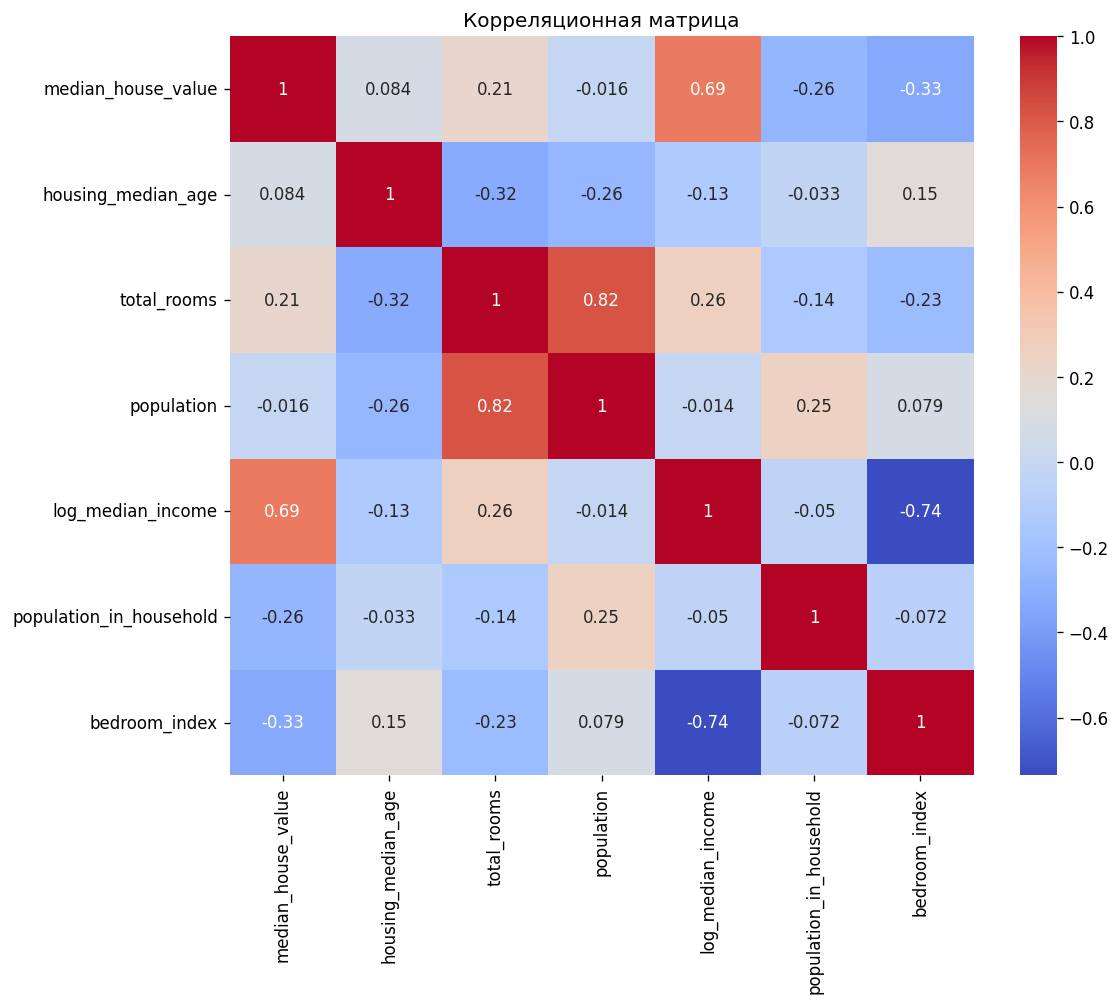

In [32]:
plot_spark_corr_matrix(df=df_filtered, input=([target]+num_cols_filtered), method='spearman')

## <a id='toc1_8_'></a>[Подготовка пайплайна](#toc0_)

Разделим на тренировочную и тестовую выборки.

In [33]:
train_data, test_data = df_filtered.randomSplit([.8,.2], seed=RANDOM_SEED)
print(train_data.count(), test_data.count())

15667 3839


In [34]:
# Для OneHotEncoder требуются признаки с числовыми значениями категорий, признаки будут помечены _idx
indexer = StringIndexer(inputCols=ohe_cols, outputCols=[c+'_idx' for c in ohe_cols], handleInvalid='skip')

# OneHotEncoder для категориальных признаков, на вход признаки после индексера _idx, на выходе будут помечены _ohe
ohe = OneHotEncoder(inputCols=[c+'_idx' for c in ohe_cols], outputCols=[c+'_ohe' for c in ohe_cols])

# Векторизуем категориальные признаки после енкодера
cat_assembler = VectorAssembler(inputCols=[c+'_ohe' for c in ohe_cols], outputCol='categorical_features')

# Для скалера трубуется векторизовать все количественные признаки
num_assembler = VectorAssembler(inputCols=num_cols_filtered, outputCol='numerical_features')

# StandardScaler для количественных признаков, на вход 1 вектор, на выходе вектор с масштабированными признаками
std_scaler = StandardScaler(inputCol='numerical_features', outputCol='numerical_features_scaled')

# Объединение обработанных категориальных и количественных признаков в 1 вектор
final_assembler = VectorAssembler(inputCols=['categorical_features','numerical_features_scaled'], outputCol="features")

# Модель линейной регрессии для всех признаков
lr_1 = LinearRegression(featuresCol="features", labelCol=target)

# Модель линейной регрессии только для количественных признаков
lr_2 = LinearRegression(featuresCol="numerical_features_scaled", labelCol=target)


In [35]:
# Пайплайн для всех признаков
pipeline_1 = Pipeline(stages=[
    indexer,
    ohe,
    cat_assembler,
    num_assembler,
    std_scaler,
    final_assembler,
    lr_1
])

# Пайплайн только для количественных признаков
pipeline_2 = Pipeline(stages=[
    num_assembler,
    std_scaler,
    lr_2
])


## <a id='toc1_9_'></a>[Оценка качества моделей](#toc0_)

In [36]:
# RMSE — среднеквадратичная ошибка
rmse_evaluator = RegressionEvaluator(
    labelCol=target,
    predictionCol='prediction',
    metricName='rmse'
)

# MAE — средняя абсолютная ошибка
mae_evaluator = RegressionEvaluator(
    labelCol=target,
    predictionCol='prediction',
    metricName='mae'
)

# R² — коэффициент детерминации
r2_evaluator = RegressionEvaluator(
    labelCol=target,
    predictionCol='prediction',
    metricName='r2'
)

Оценка качества модели, обученной на всех признаках:

In [37]:
# Обучение и получение предсказаний
predictions = pipeline_1.fit(train_data).transform(test_data)

# Метрики
rmse = rmse_evaluator.evaluate(predictions)
mae = mae_evaluator.evaluate(predictions)
r2 = r2_evaluator.evaluate(predictions)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.4f}")

RMSE: 66444.17
MAE: 50726.68
R²: 0.6633


Оценка качества модели, обученной только на количественных признаках:

In [38]:
# Обучение и получение предсказаний
predictions = pipeline_2.fit(train_data).transform(test_data)

# Метрики
rmse = rmse_evaluator.evaluate(predictions)
mae = mae_evaluator.evaluate(predictions)
r2 = r2_evaluator.evaluate(predictions)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.4f}")

RMSE: 70453.93
MAE: 53792.02
R²: 0.6215


## <a id='toc1_10_'></a>[Остановка Spark сессии](#toc0_)

In [39]:
spark.stop()

## <a id='toc1_11_'></a>[Вывод](#toc0_)

**Задачи:** 
1. Обучить модель линейной регрессии, используя и количественные, и категориальные признаки
2. Обучить модель линейной регрессии, используя только количественные признаки
3. Сравнить обе модели метриками RMSE, MAE и R2

**Этапы работы:**
1. Активация локальной Spark-сессии. 
2. Предобработка. Пропуски заполнены медианой, дубликаты не обнаружены.
3. Исследовательский анализ. Данные имели сильные выбросы во всех признаках кроме (медианного возраста жителей), получили нижнию и верхнюю границы 3 IQR для последующей фильтрации. Один признак (медианных доход жителей) логарифмировали.
4. Фильтрация данных. Был создан новый датасет с отфильтрованными данными. 
5. Корреляционный анализ. Эмпирическим путем была подобрана лучшая комбинация признаков, на основании коэффициентов корреляции. Устранена мультиколлинеарность.
6. Подготовка пайпайнов. Были созданы два пайплайна :
    - Для всех признаков. Включает кодирование OHE и стандартизацию, модель линейной регрессии. 
    - Только для количественных признаков. Включает стандартизацию и модель линейной регрессии.
7. Оценка качества. Модели обучены в среде Spark. Созаданы и получены метрики RMSE, MAE и R2 для каждой модели.
8. Остановка локальной Spark-сессии.

**Результаты**
- Фильтрация данных улучшила качество моделей за счет устранения выбросов. Рост составил около 0.04 пунктов для коэффициента детерминации R² у каждой модели. 
- Добавление категориального признака (ocean_proximity) положительно сказалось на качестве модели: ошибки RMSE и MAE снизились на 3200 пунктов, R² вырос на 0.04.
- После фильтрации остались незначительные выбросы, причем метрика RMSE более чувствительна к ним, чем MAE. Поэтому значение  среднеквадратичной ошибки больше средней абсолютной.
- Изучен фреймворк Spark. 
